# Emotion Detection for news

In [1]:
import pandas as pd


def data_extract(df, target_value):
    """
    Extracts the text and title from the dataframe and  adds a label column.
    """

    # add a target column to the dataframe
    df["label"] = target_value

    # return a df copy with text, title and label columns
    return df[["text", "title", "label"]]


DATA_CONFIG = [
    {
        "name": "BuzzFeed Fake News",
        "description": "Fake news articles from BuzzFeed.",
        "filename": "BuzzFeed_fake_news_content.csv",
        "extract_func": data_extract,
        "target_value": "FAKE",
    },
    {
        "name": "BuzzFeed Real News",
        "description": "Real news articles from BuzzFeed.",
        "filename": "BuzzFeed_real_news_content.csv",
        "extract_func": data_extract,
        "target_value": "TRUE",
    },
    {
        "name": "PolitiFact Fake News",
        "description": "Fake news articles from PolitiFact.",
        "filename": "PolitiFact_fake_news_content.csv",
        "extract_func": data_extract,
        "target_value": "FAKE",
    },
    {
        "name": "PolitiFact Real News",
        "description": "Real news articles from PolitiFact.",
        "filename": "PolitiFact_real_news_content.csv",
        "extract_func": data_extract,
        "target_value": "TRUE",
    },
    {
        "name": "Fake News - Kaggle",
        "description": "Fake news articles from various sources obtained from kaggle.",
        "filename": "Fake.csv",
        "extract_func": data_extract,
        "target_value": "FAKE"
    },
    {
        "name": "True News - Kaggle",
        "description": "True news articles from various sources obtained from kaggle.",
        "filename": "True.csv", 
        "extract_func": data_extract, 
        "target_value": "TRUE"
    },
]


def load_merge_data(data_config):
    """
    Loads and merges the data from the given config.
    """
    dataframes = []

    for config in data_config:
        filepath = f"./data/{config['filename']}"
        df = pd.read_csv(filepath)
        df = config["extract_func"](df, config["target_value"])
        dataframes.append(df)

    # concatenate all dataframes into one
    merged_df = pd.concat(dataframes, ignore_index=True)

    return merged_df


def basic_sanity_check(df):
    """
    Performs a basic sanity check on the dataframe.
    """

    # sanity check title
    print("=" * 20)
    print("{:^20}".format("Sanity Check"))
    print("=" * 20)

    # check for missing values
    if df.isnull().values.any():
        print("Missing values found in the dataframe.")
        # remove rows with missing values
        df = df.dropna()

    # check for duplicates
    if df.duplicated().any():
        # check for duplicate rows
        duplicate_rows = df.duplicated().sum()
        print(f"Duplicate rows found: {duplicate_rows}")
        # remove duplicate rows
        df = df.drop_duplicates().reset_index(drop=True)
        print("Duplicate rows removed.")

    # check for empty strings
    if (df["text"] == "").any() or (df["title"] == "").any():
        print("Empty strings found in the dataframe.")
        # remove rows with empty strings
        df = df[(df["text"] != "") & (df["title"] != "")].reset_index(drop=True)
        print("Empty strings removed.")

    # check the shape of the dataframe
    print(f"Dataframe has {df.shape[0]} rows and {df.shape[1]} columns.")
    print(f"Dataframe has {df['label'].nunique()} unique labels.")

    print("=" * 20)


def save_data(df, path):
    """
    Saves the dataframe to a csv file.
    """
    df.to_csv(path, index=False)
    print(f"Data saved to {path}")


def generate_raw_data():
    raw_data = load_merge_data(DATA_CONFIG)
    basic_sanity_check(raw_data)
    save_data(raw_data, "./data/raw_data.csv")
    return raw_data


def load_raw_data():
    """
    Loads the raw data from the given path.
    """
    filepath = "./data/raw_data.csv"

    # check if the file exists, if not generate the raw data
    try:
        df = pd.read_csv(filepath)
        print(f"Raw data loaded from {filepath}.")
    except FileNotFoundError:
        print(f"{filepath} not found. Generating raw data...")
        df = generate_raw_data()
        print(f"Raw data generated and saved to {filepath}.")
    return df

In [2]:
df_raw = load_raw_data()

Raw data loaded from ./data/raw_data.csv.


In [3]:
df_raw.head()


,text,title,label
0,I woke up this morning to find a variation of ...,Proof The Mainstream Media Is Manipulating The...,FAKE
1,Former President Bill Clinton and his Clinton ...,Charity: Clinton Foundation Distributed “Water...,FAKE
2,After collapsing just before trying to step in...,A Hillary Clinton Administration May be Entire...,FAKE
3,"Donald Trump is, well, deplorable. He’s sugges...",Trump’s Latest Campaign Promise May Be His Mos...,FAKE
4,Website is Down For Maintenance,Website is Down For Maintenance,FAKE


In [4]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download necessary resources
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("punkt_tab")
nltk.download("wordnet")

# Custom stopwords (retain "not" and "can")
STOP_WORDS = set(stopwords.words("english")) - {"not", "can"}

# custom stopwords
CUSTOM_STOP_WORDS = {"reuters", "reuter"}

# Combine the two sets of stopwords
STOP_WORDS = STOP_WORDS.union(CUSTOM_STOP_WORDS)


# Function for preprocessing
def clean_text(text):
    text = text.lower()  # Lowercase
    text = re.sub(r"\'t", " not", text)  # Expand "can't" → "can not"
    text = re.sub(r"@\w+", "", text)  # Remove @name
    text = re.sub(r"[^a-zA-Z0-9\s\?]", "", text)  # Remove special characters except "?"
    text = re.sub(r"([^\w\s\?])", "", text)  # Remove punctuations except "?"
    text = re.sub(
        r"\s+", " ", text
    ).strip()  # Remove extra spaces and trailing whitespaces
    text = re.sub(r"\s+", " ", text)  # Remove extra spaces

    # remove stopwords
    text = " ".join([word for word in text.split() if word not in STOP_WORDS])

    return text


# function to tokenize the text and remove stopwords
def tokenize_text(text):
    # Tokenize the text
    tokens = word_tokenize(text)
    # Remove stopwords
    tokens = [word for word in tokens if word not in STOP_WORDS]
    return tokens


def lemmatize_tokens(tokens):   
    lemmatizer = WordNetLemmatizer()
    return [lemmatizer.lemmatize(token) for token in tokens]


def preprocess_data(df):
    """
    Preprocess the data by cleaning the text and removing stopwords.
    """
    # clean title
    df["title"] = df["title"].apply(clean_text)

    # clean text
    df["text"] = df["text"].apply(clean_text)

    # create a new column called 'news', by merging the 'title' and 'text' columns
    df["news"] = df["title"] + " " + df["text"]

    # tokenize the news text and remove stopwords
    df["tokens"] = df["news"].apply(tokenize_text)

    # lemmatize the tokens
    df["tokens"] = df["tokens"].apply(lemmatize_tokens)

    # merge the tokens into a single string
    df["cleaned_news"] = df["tokens"].apply(lambda x: " ".join(x))

    # return all columns in order
    df_cleaned = df[["title", "text", "news", "tokens", "cleaned_news", "label"]]

    return df_cleaned


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\u3253992\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\u3253992\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\u3253992\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\u3253992\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [5]:
df = preprocess_data(df_raw)
df.head()

,title,text,news,tokens,cleaned_news,label
0,proof mainstream media manipulating election t...,woke morning find variation headline splashed ...,proof mainstream media manipulating election t...,"[proof, mainstream, medium, manipulating, elec...",proof mainstream medium manipulating election ...,FAKE
1,charity clinton foundation distributed watered...,former president bill clinton clinton health a...,charity clinton foundation distributed watered...,"[charity, clinton, foundation, distributed, wa...",charity clinton foundation distributed watered...,FAKE
2,hillary clinton administration may entirely ru...,collapsing trying step van removed 911 ceremon...,hillary clinton administration may entirely ru...,"[hillary, clinton, administration, may, entire...",hillary clinton administration may entirely ru...,FAKE
3,trumps latest campaign promise may horrible on...,donald trump well deplorable hes suggested bui...,trumps latest campaign promise may horrible on...,"[trump, latest, campaign, promise, may, horrib...",trump latest campaign promise may horrible one...,FAKE
4,website maintenance,website maintenance,website maintenance website maintenance,"[website, maintenance, website, maintenance]",website maintenance website maintenance,FAKE


In [6]:
df_copy = df.copy()

In [7]:

import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

def load_data(df: pd.DataFrame) -> pd.DataFrame:
    # df['text_transformer'] = df['title'] + df['text']
    df['label'] = np.where(df['label'] == "FAKE", 0, 1)
    return df[['cleaned_news', 'label']]


def load_model_and_tokenizer(model_name: str):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name)
    return tokenizer, model

def create_pipeline(model, tokenizer):
    device = 0 if torch.cuda.is_available() else -1
    return pipeline(
        "text-classification",
        model=model,
        tokenizer=tokenizer,
        device=device,
        truncation=True,
        padding=True
    )

In [8]:
device = 0 if torch.cuda.is_available() else -1
torch.cuda.is_available()

True

In [9]:
import os
os.environ['CUDA_LAUNCH_BLOCKING']="1"
os.environ['TORCH_USE_CUDA_DSA'] = "1"

model_name = "j-hartmann/emotion-english-distilroberta-base"

df_model = load_data(df_copy.copy())

tokenizer, model = load_model_and_tokenizer(model_name)
emotion_pipeline = create_pipeline(model, tokenizer)

Device set to use cuda:0


In [11]:
predictions = emotion_pipeline(df_model['cleaned_news'].tolist(), truncation=True, padding=True)

In [12]:
predictions

[{'label': 'fear', 'score': 0.8142101168632507},
 {'label': 'fear', 'score': 0.9458658695220947},
 {'label': 'surprise', 'score': 0.47892189025878906},
 {'label': 'fear', 'score': 0.9514607787132263},
 {'label': 'neutral', 'score': 0.6287482976913452},
 {'label': 'joy', 'score': 0.5452633500099182},
 {'label': 'surprise', 'score': 0.4495931565761566},
 {'label': 'fear', 'score': 0.6063956022262573},
 {'label': 'joy', 'score': 0.3064725697040558},
 {'label': 'sadness', 'score': 0.8882355093955994},
 {'label': 'sadness', 'score': 0.4668644368648529},
 {'label': 'fear', 'score': 0.5080348253250122},
 {'label': 'surprise', 'score': 0.47892189025878906},
 {'label': 'fear', 'score': 0.9510830044746399},
 {'label': 'surprise', 'score': 0.5122034549713135},
 {'label': 'fear', 'score': 0.9842408299446106},
 {'label': 'anger', 'score': 0.6487006545066833},
 {'label': 'fear', 'score': 0.7338570356369019},
 {'label': 'anger', 'score': 0.70956951379776},
 {'label': 'fear', 'score': 0.78788745403289

In [14]:
df_model['emotions'] = [pred['label'] for pred in predictions]

df_model.head()

,cleaned_news,label,predictions,emotions
0,proof mainstream medium manipulating election ...,0,fear,fear
1,charity clinton foundation distributed watered...,0,fear,fear
2,hillary clinton administration may entirely ru...,0,surprise,surprise
3,trump latest campaign promise may horrible one...,0,fear,fear
4,website maintenance website maintenance,0,neutral,neutral


In [17]:
df_final = df_model[["cleaned_news", "emotions", "label"]].copy()

df_final.head()

,cleaned_news,emotions,label
0,proof mainstream medium manipulating election ...,fear,0
1,charity clinton foundation distributed watered...,fear,0
2,hillary clinton administration may entirely ru...,surprise,0
3,trump latest campaign promise may horrible one...,fear,0
4,website maintenance website maintenance,neutral,0


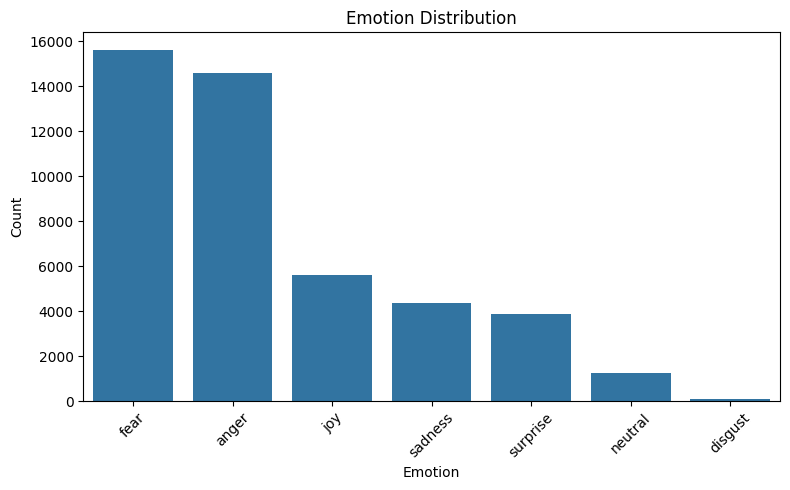

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Countplot of emotion distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df_final, x='emotions', order=df_final['emotions'].value_counts().index)

plt.title('Emotion Distribution')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

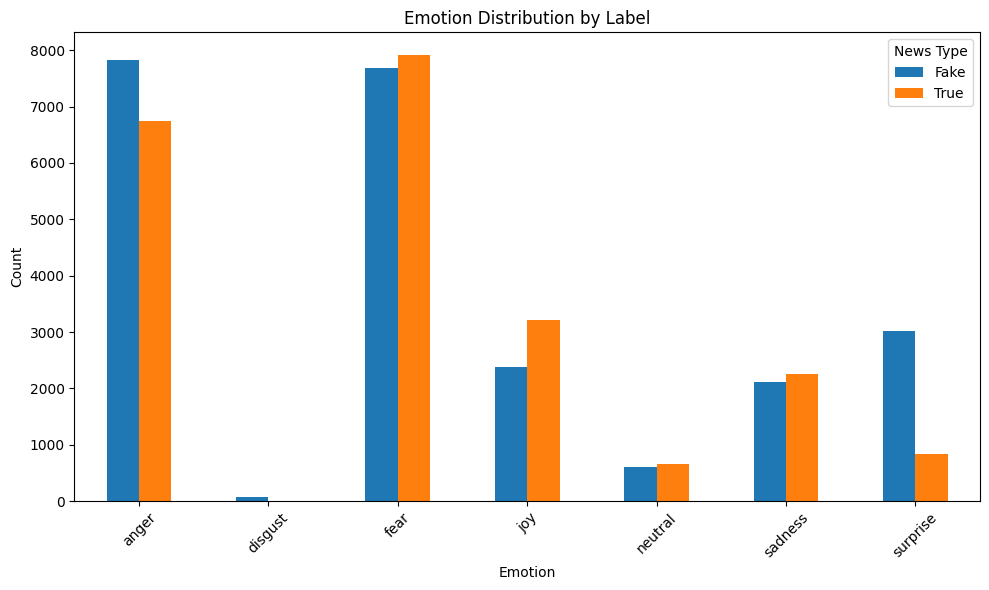

In [20]:
# If 'label' is numeric: 0 = Fake, 1 = True
df_final['label_name'] = df_final['label'].map({0: 'Fake', 1: 'True'})

# Group by label and emotion
grouped = df_final.groupby(['label_name', 'emotions']).size().unstack(fill_value=0)

# Plot grouped bar chart
grouped.T.plot(kind='bar', figsize=(10, 6))

plt.title('Emotion Distribution by Label')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='News Type')
plt.tight_layout()
plt.show()